# Week1_ex4_analysis - Skin Depth vs Plate Thickness (Light Check)

![Week1_ex4 model](Images/Week1_ex4_result_image.png)

This is a light check rather than a full deep-dive: the aluminum plate has a square cutout and an off-center coil, so there's no simple closed-form field solution to compare the FEM result against. Instead, this notebook checks whether the 200 Hz skin depth is consistent with where the eddy currents should actually concentrate in the 19 mm plate.

$$\delta = \sqrt{\frac{2}{\omega\mu\sigma}}$$

Nothing here needs an AEDT session — the plate thickness and coil frequency are just the values already set in `Week1_ex4.ipynb`, and aluminum's conductivity is a standard material-library constant.

In [1]:
# 1. Aluminum is non-magnetic, and its bulk conductivity is a standard material-library value
import numpy as np
import pandas as pd

sigma = 3.8e7  # S/m
mu = 4 * np.pi * 1e-7  # H/m, mu_r = 1
freq = 200  # Hz, matches Setup1's Frequency in Week1_ex4.ipynb

# 2. Skin depth from the standard low-frequency EddyCurrent formula
omega = 2 * np.pi * freq
skin_depth = np.sqrt(2 / (omega * mu * sigma))

# 3. Compare against the Stock's 19 mm thickness (from the geometry cell in Week1_ex4.ipynb)
thickness = 19e-3  # m

summary_df = pd.DataFrame({
    "parameter": ["frequency_Hz", "conductivity_S_per_m", "skin_depth_mm", "plate_thickness_mm", "thickness_over_skin_depth"],
    "value": [freq, sigma, skin_depth * 1e3, thickness * 1e3, thickness / skin_depth]
})
summary_df

,parameter,value
0,frequency_Hz,2.000000e+02
1,conductivity_S_per_m,3.800000e+07
2,skin_depth_mm,5.773157e+00
3,plate_thickness_mm,1.900000e+01
4,thickness_over_skin_depth,3.291094e+00


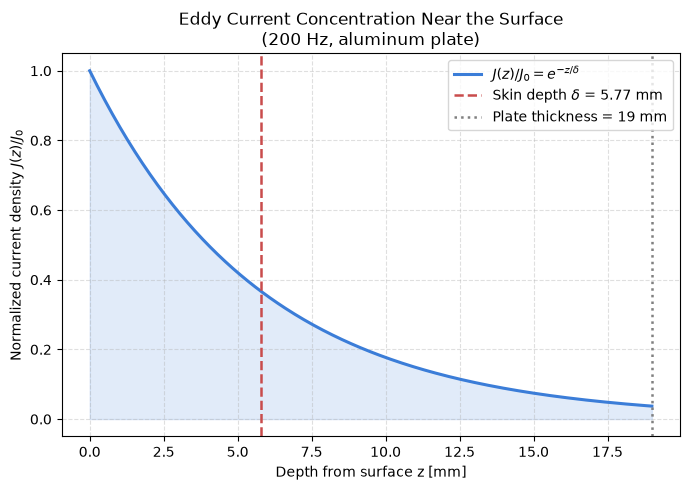

In [2]:
# 4. Current-density decay profile from one face, normalized to the surface value
import matplotlib.pyplot as plt

z = np.linspace(0, thickness, 300)
J_over_J0 = np.exp(-z / skin_depth)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(z * 1e3, J_over_J0, color="#3b7dd8", linewidth=2.2, label="$J(z)/J_0 = e^{-z/\\delta}$")
ax.axvline(skin_depth * 1e3, color="#c94c4c", linestyle="--", linewidth=1.8,
           label=f"Skin depth $\\delta$ = {skin_depth*1e3:.2f} mm")
ax.axvline(thickness * 1e3, color="gray", linestyle=":", linewidth=1.8,
           label=f"Plate thickness = {thickness*1e3:.0f} mm")
ax.fill_between(z * 1e3, J_over_J0, alpha=0.15, color="#3b7dd8")
ax.set_xlabel("Depth from surface z [mm]")
ax.set_ylabel("Normalized current density $J(z)/J_0$")
ax.set_title("Eddy Current Concentration Near the Surface\n(200 Hz, aluminum plate)")
ax.legend()
ax.grid(linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("Images/Week1_ex4_skin_depth_profile.png", dpi=150, bbox_inches="tight")
plt.show()

## Conclusion

Skin depth comes out to about 5.8 mm against the 19 mm plate — roughly 3.3x thicker than one skin depth. The decay curve above shows current density dropping to about 5% of its surface value by the time it reaches the plate's mid-thickness, so eddy currents concentrate noticeably near the two faces rather than spreading uniformly through the full 19 mm. It's not an extreme skin effect (that would need a much larger thickness-to-δ ratio), but the order-of-magnitude check matches the qualitative expectation. No further analysis needed on this exercise.